# Prueba - Análisis estadístico con Python
## Daniel Rojas López

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sci
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, classification_report



### 1. Carga los datos y explóralos. Elimina los datos nulos o incorrectos


In [26]:
# Cargar el dataset de salarios
df = pd.read_csv("cardio.csv",delimiter=',')
df.shape


(4238, 16)

In [27]:
#eliminar datos nulos o incorrectos
df = df.dropna()
df.shape

(3656, 16)

### 2. Escoge tres variables cuantitativas y realiza un análisis descriptivo de ellas, utilizando indicadores y gráficos. ¿Cuaĺ presenta mayor dispersión?


In [28]:
df.head(10)

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,M,39,4.0,No,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,F,46,2.0,No,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,M,48,1.0,Yes,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,F,61,3.0,Yes,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,F,46,3.0,Yes,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,F,43,2.0,No,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,F,63,1.0,No,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,F,45,2.0,Yes,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,M,52,1.0,No,0.0,0.0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,M,43,1.0,Yes,30.0,0.0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


In [29]:
df_edad = df[['age']].copy()
mean_edad = df_edad['age'].mean()
std_edad = df_edad['age'].std()
df_edad.describe()




,age
count,3656.000000
mean,49.557440
std,8.561133
min,32.000000
25%,42.000000
50%,49.000000
75%,56.000000
max,70.000000


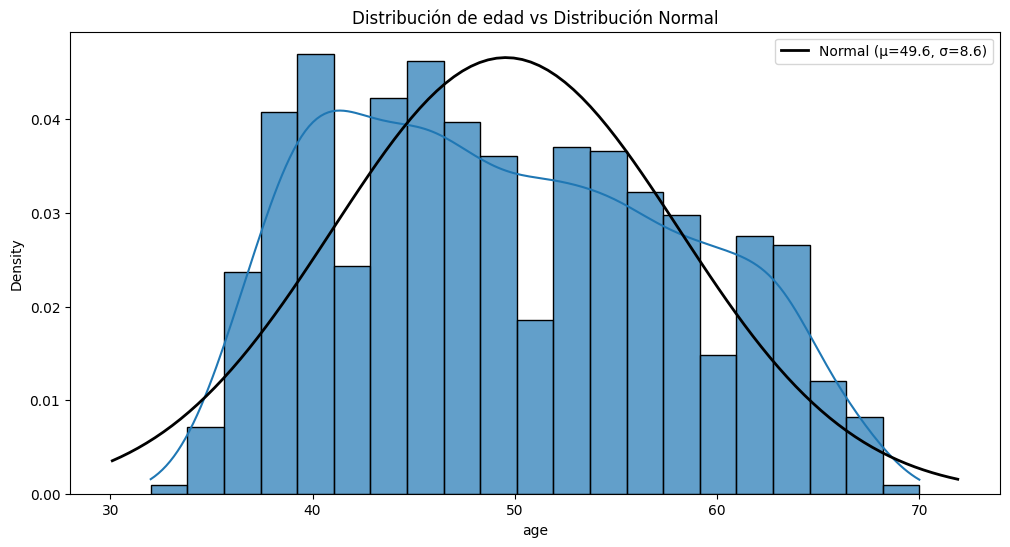

In [30]:
plt.figure(figsize=(12, 6))
sns.histplot(df_edad['age'], kde=True, stat='density', alpha=0.7)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = sci.norm.pdf(x, mean_edad, std_edad)  # Ahora sí funcionará
plt.plot(x, p, 'k', linewidth=2, label=f'Normal (μ={mean_edad:.1f}, σ={std_edad:.1f})')
plt.legend()
plt.title('Distribución de edad vs Distribución Normal')
plt.show()  

In [31]:
df_pulsaciones_corazon = df[['heartRate']].copy()
df_pulsaciones_corazon.describe()

,heartRate
count,3656.000000
mean,75.730580
std,11.982952
min,44.000000
25%,68.000000
50%,75.000000
75%,82.000000
max,143.000000


In [32]:
df_gludosa = df[['glucose']].copy()
df_gludosa.describe()

,glucose
count,3656.000000
mean,81.856127
std,23.910128
min,40.000000
25%,71.000000
50%,78.000000
75%,87.000000
max,394.000000


In [33]:

# se seleccionan las columnas numéricas elegidas para verificar si existe correlación entre ellas
df_seleccionada = df[['age', 'heartRate', 'glucose']].copy()
df_seleccionada.head()


,age,heartRate,glucose
0,39,80.0,77.0
1,46,95.0,76.0
2,48,75.0,70.0
3,61,65.0,103.0
4,46,85.0,85.0


In [34]:
for col in df_seleccionada.columns:
    if df_seleccionada[col].dtype == 'object':
        # Remover símbolos de porcentaje, comas y otros caracteres
        df_seleccionada[col] = df_seleccionada[col].astype(str).str.replace('%', '').str.replace(',', '').str.replace('$', '').str.replace(' ', '')
        # Convertir a numérico
        df_seleccionada[col] = pd.to_numeric(df_seleccionada[col], errors='coerce')

# Calcular matriz de correlación
correlation_matrix = df_seleccionada.corr()

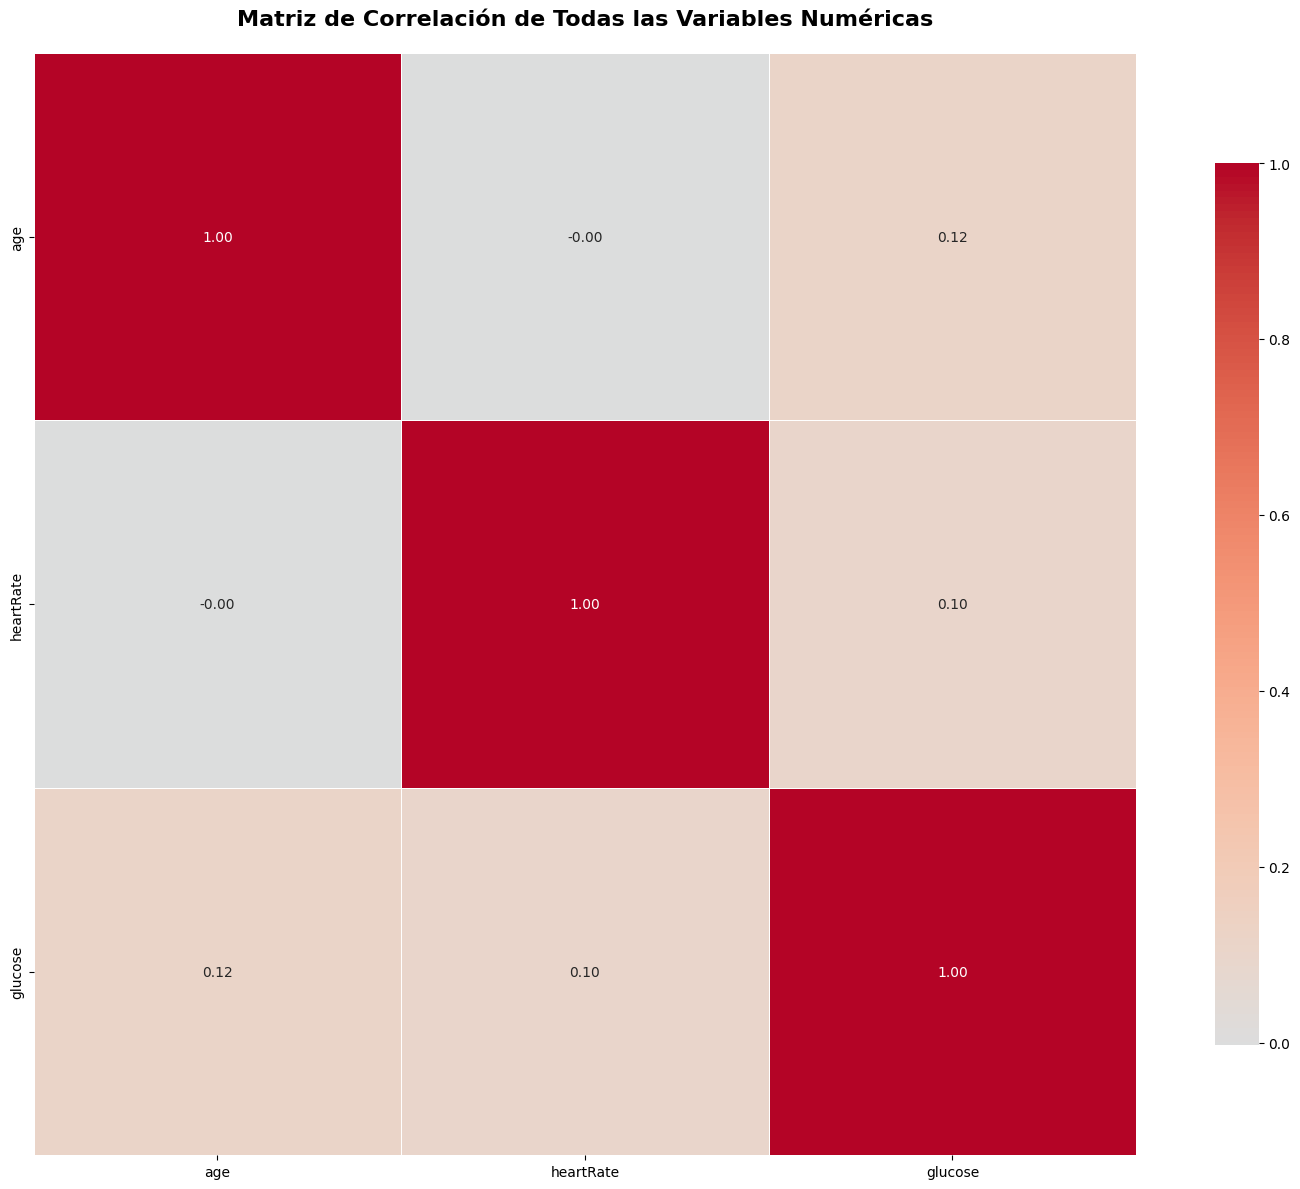

In [35]:
# Crear el heatmap
plt.figure(figsize=(16, 12))

# Configurar el heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,           # Mostrar valores de correlación
    cmap='coolwarm',      # Esquema de colores (rojo=positivo, azul=negativo)
    center=0,             # Centrar el colormap en 0
    square=True,          # Hacer las celdas cuadradas
    linewidths=0.5,       # Líneas entre celdas
    cbar_kws={"shrink": 0.8},  # Configurar barra de color
    fmt='.2f'            # Formato de números (2 decimales)
)

plt.title('Matriz de Correlación de Todas las Variables Numéricas', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

No existe una correlación significativa entre las variables numéricas del dataset.

### 3. Elimina los datos atípicos del dataset. Para las siguientes preguntas, considera el dataset "limpio"


In [36]:
#eliminar datos atipicos de la columna age 

# calculando IQR por age
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

# definiendo los bounds de los outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# removiendo los outliers
df_limpio = df[(df['age'] >= lower_bound) & (df['age'] <= upper_bound)]

print(f"Original dataset size: {len(df)}")
print(f"Clean dataset size: {len(df_limpio)}")
print(f"Removed outliers: {len(df) - len(df_limpio)}")

Original dataset size: 3656
Clean dataset size: 3656
Removed outliers: 0


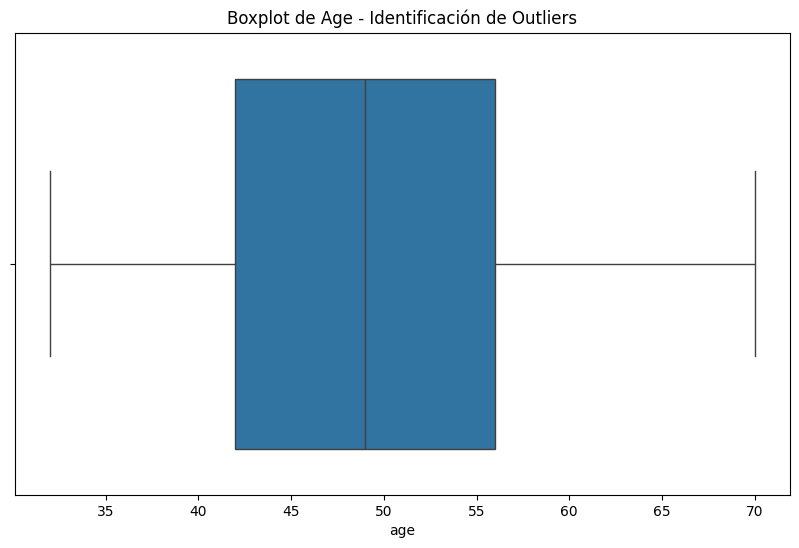

In [37]:
# Boxplot to visualize outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['age'])
plt.title('Boxplot de Age - Identificación de Outliers')
plt.show()

# Then apply IQR method
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[(df['age'] >= Q1 - 1.5 * IQR) & (df['age'] <= Q3 + 1.5 * IQR)]

### 4. ¿Qué variables cuantitativas presentan mayor correlación? Explica.


In [38]:
# Seleccionar solo columnas numéricas
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

# Limpiar y convertir datos numéricos
df_numeric = df[numeric_columns].copy()

# Convertir columnas con símbolos y formato
for col in df_numeric.columns:
    if df_numeric[col].dtype == 'object':
        # Remover símbolos de porcentaje, comas y otros caracteres
        df_numeric[col] = df_numeric[col].astype(str).str.replace('%', '').str.replace(',', '').str.replace('$', '').str.replace(' ', '')
        # Convertir a numérico
        df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce')

# Calcular matriz de correlación
correlation_matrix = df_numeric.corr()

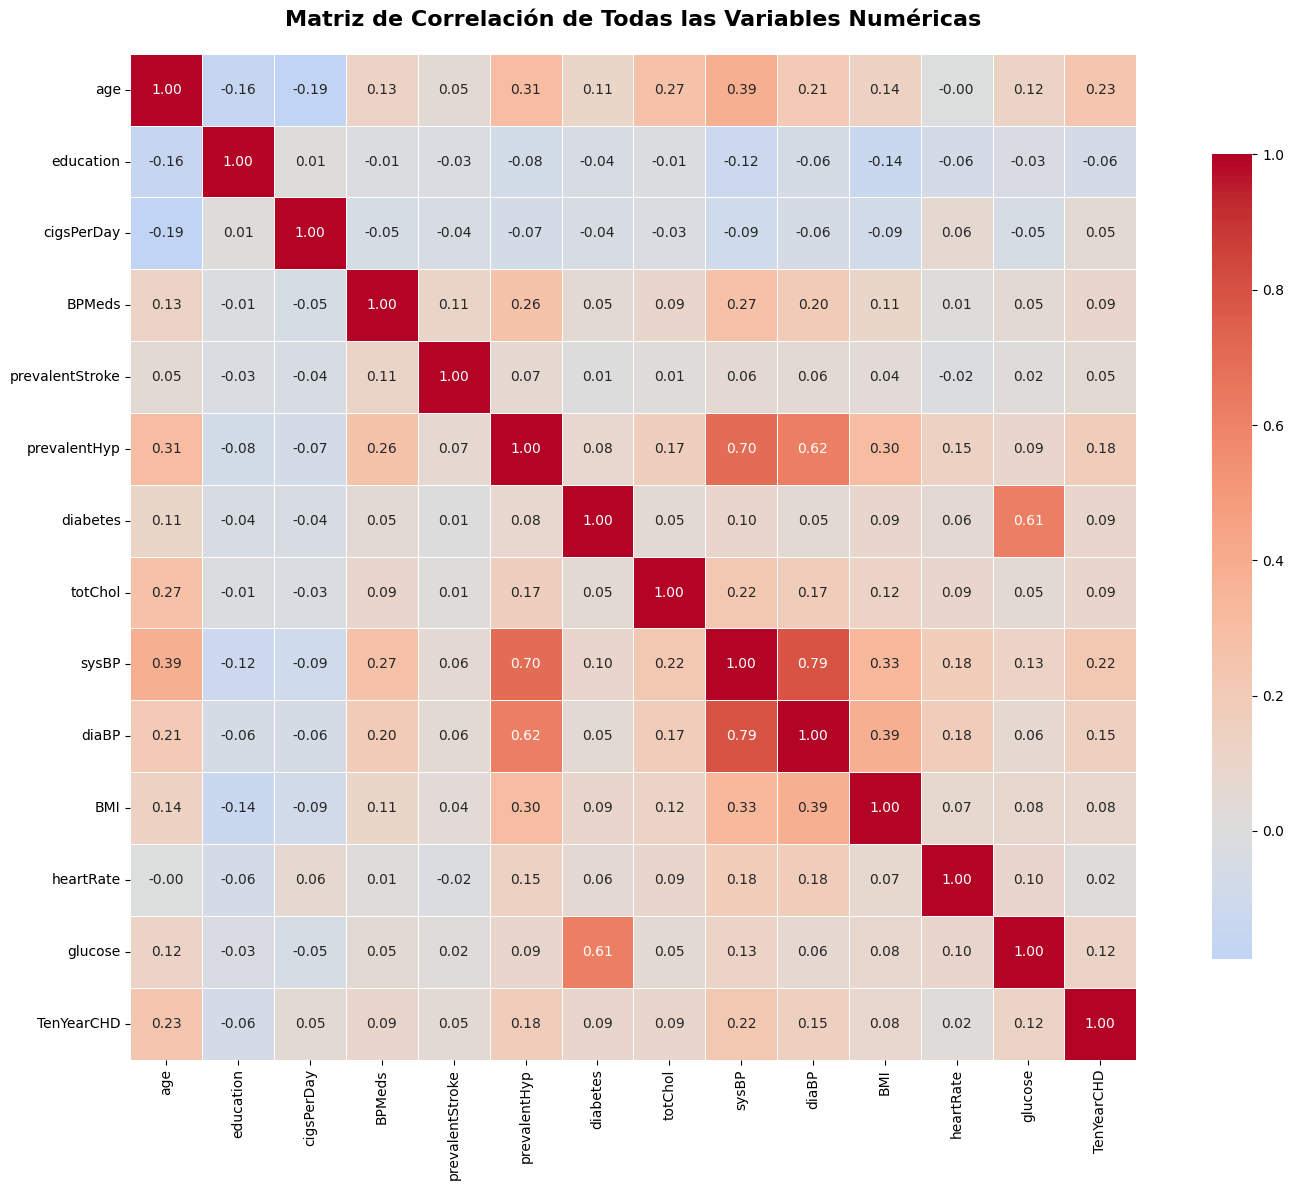

In [39]:
# Crear el heatmap
plt.figure(figsize=(16, 12))

# Configurar el heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,           # Mostrar valores de correlación
    cmap='coolwarm',      # Esquema de colores (rojo=positivo, azul=negativo)
    center=0,             # Centrar el colormap en 0
    square=True,          # Hacer las celdas cuadradas
    linewidths=0.5,       # Líneas entre celdas
    cbar_kws={"shrink": 0.8},  # Configurar barra de color
    fmt='.2f'            # Formato de números (2 decimales)
)

plt.title('Matriz de Correlación de Todas las Variables Numéricas', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Entre las variable que mas correlacion tienen con la variable target son:

° sysBP y diaBP
° sysBP y prevalentHyp

y las que menos correlacion tienen son:

° CigsPerDay y age



### 5. Si de este dataset se escoge un paciente al azar, ¿cuál es la probabilidad de que sea hombre, si se sabe que pertenece al mayor cuartil de la variable correspondiente al índice de masa corporal?


In [40]:
# Calcular cuartiles de BMI
Q1_BMI = df['BMI'].quantile(0.25)
Q2_BMI = df['BMI'].quantile(0.50) 
Q3_BMI = df['BMI'].quantile(0.75)
Q4_BMI = df['BMI'].quantile(1.0)

print(f"Cuartiles de BMI:")
print(f"Q1 (25%): {Q1_BMI:.2f}")
print(f"Q2 (50%): {Q2_BMI:.2f}")
print(f"Q3 (75%): {Q3_BMI:.2f}")
print(f"Q4 (100%): {Q4_BMI:.2f}")

# Filtrar pacientes en el cuartil más alto de BMI (>= percentil 75)
pacientes_bmi_alto = df[df['BMI'] >= Q3_BMI]

print(f"\nTotal pacientes en cuartil más alto de BMI: {len(pacientes_bmi_alto)}")

# Contar hombres en cuartil más alto de BMI
hombres_bmi_alto = pacientes_bmi_alto[pacientes_bmi_alto['sex'] == 'M']

print(f"Hombres en cuartil más alto de BMI: {len(hombres_bmi_alto)}")

# Calcular probabilidad condicional
prob_hombre_dado_bmi_alto = len(hombres_bmi_alto) / len(pacientes_bmi_alto)

print(f"\nP(Hombre | BMI más alto) = {prob_hombre_dado_bmi_alto:.4f}")
print(f"Probabilidad = {prob_hombre_dado_bmi_alto * 100:.2f}%")

# Análisis adicional
print(f"\nDistribución de género en cuartil más alto de BMI:")
conteo_genero = pacientes_bmi_alto['sex'].value_counts()
print(conteo_genero)
print(f"Porcentaje hombres: {(conteo_genero['M'] / len(pacientes_bmi_alto)) * 100:.2f}%")
print(f"Porcentaje mujeres: {(conteo_genero['F'] / len(pacientes_bmi_alto)) * 100:.2f}%")

Cuartiles de BMI:
Q1 (25%): 23.08
Q2 (50%): 25.38
Q3 (75%): 28.04
Q4 (100%): 56.80

Total pacientes en cuartil más alto de BMI: 915
Hombres en cuartil más alto de BMI: 448

P(Hombre | BMI más alto) = 0.4896
Probabilidad = 48.96%

Distribución de género en cuartil más alto de BMI:
sex
F    467
M    448
Name: count, dtype: int64
Porcentaje hombres: 48.96%
Porcentaje mujeres: 51.04%


### 6. ¿Es razonable afirmar que, para una persona cualquiera (no necesariamente dentro del dataset), su ritmo cardiaco promedio es 75? Explica y justifica.


Análisis de Ritmo Cardíaco:
Media muestral: 75.73
Desviación estándar: 11.98
Tamaño muestral: 3656

Prueba de Hipótesis (H0: μ = 75):
Estadístico t: 3.6864
Valor p: 0.0002
Intervalo de confianza 95%: (75.34, 76.12)

Conclusión: Rechazamos H0 (p < 0.05)
No es razonable afirmar que el ritmo cardíaco promedio es 75


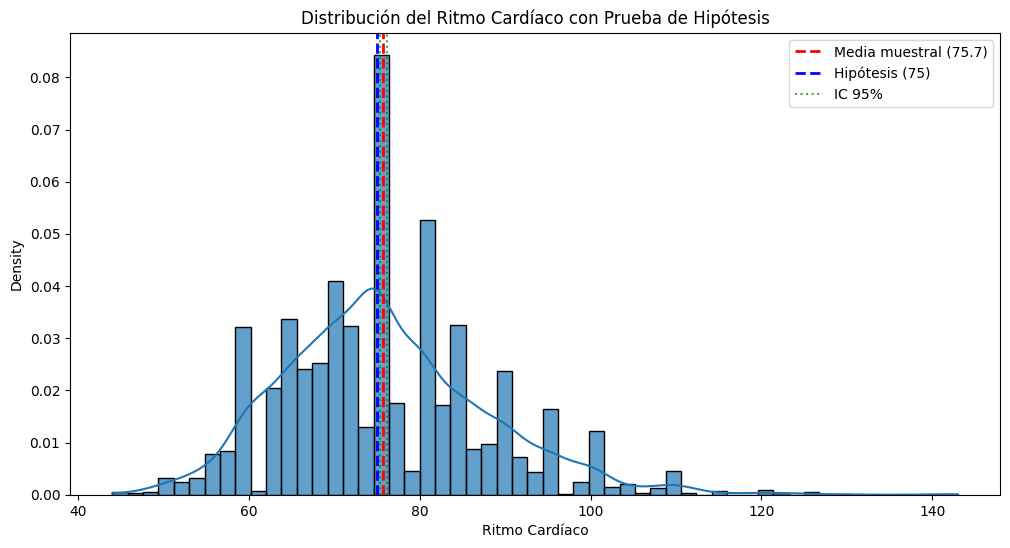

In [41]:
# Prueba de hipótesis para el ritmo cardíaco promedio
# H0: μ = 75 (el ritmo cardíaco promedio es 75)
# H1: μ ≠ 75 (el ritmo cardíaco promedio es diferente de 75)


# Extraer los datos de ritmo cardíaco
heart_rate_data = df['heartRate'].dropna()

# Realizar prueba t de una muestra
t_statistic, p_value = sci.ttest_1samp(heart_rate_data, 75)

# Calcular estadísticas descriptivas
mean_hr = heart_rate_data.mean()
std_hr = heart_rate_data.std()
n = len(heart_rate_data)

# Calcular intervalo de confianza al 95%
confidence_level = 0.95
degrees_freedom = n - 1
t_critical = sci.t.ppf((1 + confidence_level) / 2, degrees_freedom)
margin_error = t_critical * (std_hr / np.sqrt(n))
confidence_interval = (mean_hr - margin_error, mean_hr + margin_error)

print(f"Análisis de Ritmo Cardíaco:")
print(f"Media muestral: {mean_hr:.2f}")
print(f"Desviación estándar: {std_hr:.2f}")
print(f"Tamaño muestral: {n}")
print(f"\nPrueba de Hipótesis (H0: μ = 75):")
print(f"Estadístico t: {t_statistic:.4f}")
print(f"Valor p: {p_value:.4f}")
print(f"Intervalo de confianza 95%: ({confidence_interval[0]:.2f}, {confidence_interval[1]:.2f})")

# Interpretación
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusión: Rechazamos H0 (p < {alpha})")
    print("No es razonable afirmar que el ritmo cardíaco promedio es 75")
else:
    print(f"\nConclusión: No rechazamos H0 (p ≥ {alpha})")
    print("Es razonable afirmar que el ritmo cardíaco promedio es 75")

# Visualización
plt.figure(figsize=(12, 6))
sns.histplot(heart_rate_data, kde=True, stat='density', alpha=0.7)
plt.axvline(mean_hr, color='red', linestyle='--', linewidth=2, label=f'Media muestral ({mean_hr:.1f})')
plt.axvline(75, color='blue', linestyle='--', linewidth=2, label='Hipótesis (75)')
plt.axvline(confidence_interval[0], color='green', linestyle=':', alpha=0.7, label='IC 95%')
plt.axvline(confidence_interval[1], color='green', linestyle=':', alpha=0.7)
plt.legend()
plt.title('Distribución del Ritmo Cardíaco con Prueba de Hipótesis')
plt.xlabel('Ritmo Cardíaco')
plt.show()

1. Planteamiento de hipótesis:
    - H₀: μ = 75 (el ritmo cardíaco promedio poblacional es 75)
    - H₁: μ ≠ 75 (el ritmo cardíaco promedio es diferente de 75)
2. Prueba estadística: Usamos t-test de una muestra porque:
   - Comparamos una media muestral con un valor hipotético
   - No conocemos la desviación estándar poblacional
   - El tamaño de muestra es grande (n > 30)
3. Criterio de decisión: Si p < 0.05, rechazamos H₀

### 7. Ser hombre, ¿influye en el promedio de cigarrillos consumidos por día, dentro de los pacientes fumadores? Explica.


Total de fumadores: 1788
Distribución de género entre fumadores:
sex
M    981
F    807
Name: count, dtype: int64

Estadísticas descriptivas:
Hombres fumadores: 981
  Media: 22.23
  Desv. estándar: 10.85
Mujeres fumadoras: 807
  Media: 13.86
  Desv. estándar: 8.76

Prueba de Hipótesis (H0: μ_hombres = μ_mujeres):
Estadístico t: 17.6799
Valor p: 0.0000

Conclusión: Rechazamos H0 (p < 0.05)
Ser hombre SÍ influye en el promedio de cigarrillos consumidos por día

Diferencia de medias (Hombres - Mujeres): 8.37 cigarrillos/día


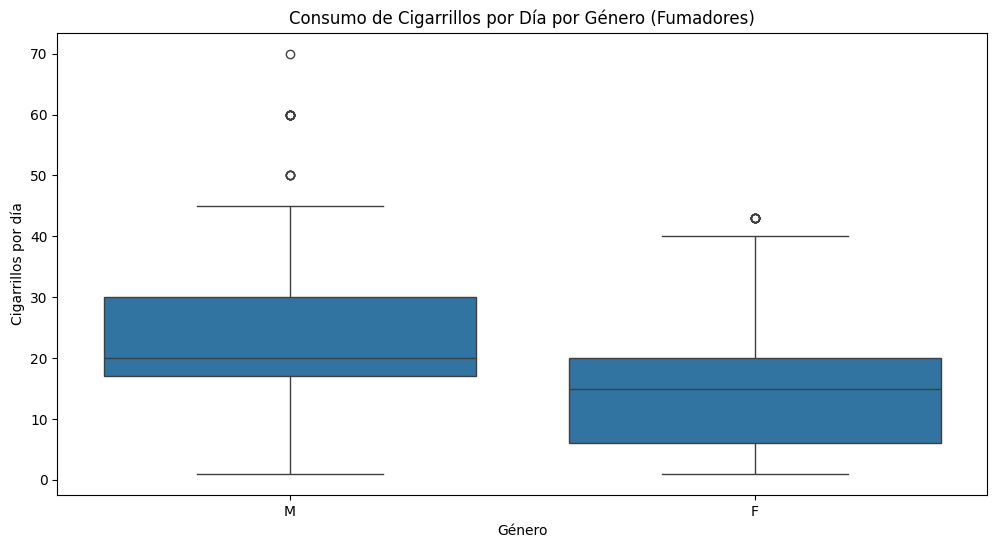

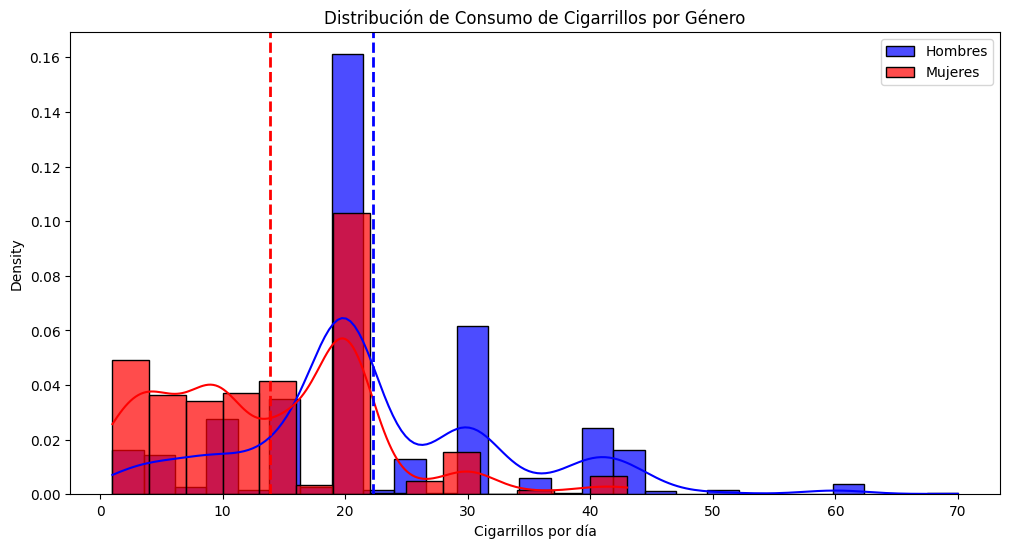

In [42]:
# Análisis: ¿Influye ser hombre en el consumo de cigarrillos?
# H0: μ_hombres = μ_mujeres (no hay diferencia en el consumo promedio)
# H1: μ_hombres ≠ μ_mujeres (hay diferencia en el consumo promedio)

# Filtrar solo pacientes fumadores
fumadores = df[df['currentSmoker'] == 'Yes'].copy()

print(f"Total de fumadores: {len(fumadores)}")
print(f"Distribución de género entre fumadores:")
print(fumadores['sex'].value_counts())

# Separar por género
hombres_fumadores = fumadores[fumadores['sex'] == 'M']['cigsPerDay'].dropna()
mujeres_fumadoras = fumadores[fumadores['sex'] == 'F']['cigsPerDay'].dropna()

print(f"\nEstadísticas descriptivas:")
print(f"Hombres fumadores: {len(hombres_fumadores)}")
print(f"  Media: {hombres_fumadores.mean():.2f}")
print(f"  Desv. estándar: {hombres_fumadores.std():.2f}")
print(f"Mujeres fumadoras: {len(mujeres_fumadoras)}")
print(f"  Media: {mujeres_fumadoras.mean():.2f}")
print(f"  Desv. estándar: {mujeres_fumadoras.std():.2f}")

# Realizar prueba t de dos muestras independientes
t_stat, p_value = sci.ttest_ind(hombres_fumadores, mujeres_fumadoras)

print(f"\nPrueba de Hipótesis (H0: μ_hombres = μ_mujeres):")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretación
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusión: Rechazamos H0 (p < {alpha})")
    print("Ser hombre SÍ influye en el promedio de cigarrillos consumidos por día")
else:
    print(f"\nConclusión: No rechazamos H0 (p ≥ {alpha})")
    print("Ser hombre NO influye en el promedio de cigarrillos consumidos por día")

# Calcular diferencia de medias y efecto
diferencia_medias = hombres_fumadores.mean() - mujeres_fumadoras.mean()
print(f"\nDiferencia de medias (Hombres - Mujeres): {diferencia_medias:.2f} cigarrillos/día")

# Visualización
plt.figure(figsize=(12, 6))
sns.boxplot(data=fumadores, x='sex', y='cigsPerDay')
plt.title('Consumo de Cigarrillos por Día por Género (Fumadores)')
plt.xlabel('Género')
plt.ylabel('Cigarrillos por día')
plt.show()

# Histogramas comparativos
plt.figure(figsize=(12, 6))
sns.histplot(hombres_fumadores, kde=True, stat='density', alpha=0.7, label='Hombres', color='blue')
sns.histplot(mujeres_fumadoras, kde=True, stat='density', alpha=0.7, label='Mujeres', color='red')
plt.axvline(hombres_fumadores.mean(), color='blue', linestyle='--', linewidth=2)
plt.axvline(mujeres_fumadoras.mean(), color='red', linestyle='--', linewidth=2)
plt.legend()
plt.title('Distribución de Consumo de Cigarrillos por Género')
plt.xlabel('Cigarrillos por día')
plt.show()

1. Filtrado de datos: Nos enfocamos solo en pacientes fumadores (currentSmoker == 'Yes')
2. Planteamiento de hipótesis:
   - H₀: μ_hombres = μ_mujeres (no hay diferencia en consumo)
   - H₁: μ_hombres ≠ μ_mujeres (hay diferencia en consumo)
3. Prueba estadística: Usamos t-test de dos muestras independientes porque:
   - Comparamos medias de dos grupos independientes (hombres vs mujeres)
   - Los grupos son independientes (una persona no puede ser ambos géneros)
4. Criterio de decisión: Si p < 0.05, rechazamos H₀

### 8. Construye un modelo de regresión lineal que permita relacionar 6 variables del dataset con el índice de masa corporal. (Debes incluir al menos dos variables cualitativas). Evalúa tu modelo y explica.


In [43]:
# Modelo de Regresión Lineal Múltiple para predecir BMI


# Seleccionar variables (2 cualitativas + 4 cuantitativas)
variables_cualitativas = ['sex', 'currentSmoker']
variables_cuantitativas = ['age', 'heartRate', 'sysBP', 'glucose']

# Crear copia del dataset
df_regresion = df[['BMI'] + variables_cualitativas + variables_cuantitativas].copy()
df_regresion = df_regresion.dropna()

print(f"Dataset para regresión: {df_regresion.shape}")
print(f"Variables predictoras: {variables_cualitativas + variables_cuantitativas}")
print(f"Variable objetivo: BMI")

# Codificar variables cualitativas
label_encoders = {}
for col in variables_cualitativas:
    le = LabelEncoder()
    df_regresion[col + '_encoded'] = le.fit_transform(df_regresion[col])
    label_encoders[col] = le
    print(f"Codificación {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Preparar X e y
X = df_regresion[variables_cuantitativas + [col + '_encoded' for col in variables_cualitativas]]
y = df_regresion['BMI']

print(f"\nVariables finales en el modelo:")
for i, col in enumerate(X.columns):
    print(f"  X{i+1}: {col}")

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Construir modelo con sklearn
modelo_sklearn = LinearRegression()
modelo_sklearn.fit(X_train, y_train)

# Hacer predicciones
y_pred_train = modelo_sklearn.predict(X_train)
y_pred_test = modelo_sklearn.predict(X_test)

# Evaluar modelo
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"\nEvaluación del Modelo:")
print(f"R² entrenamiento: {r2_train:.4f}")
print(f"R² prueba: {r2_test:.4f}")
print(f"MSE entrenamiento: {mse_train:.4f}")
print(f"MSE prueba: {mse_test:.4f}")
print(f"MAE entrenamiento: {mae_train:.4f}")
print(f"MAE prueba: {mae_test:.4f}")

# Análisis detallado con statsmodels
X_train_sm = sm.add_constant(X_train)
modelo_stats = sm.OLS(y_train, X_train_sm).fit()

print(f"\nResumen del Modelo:")
print(modelo_stats.summary())

# Coeficientes e interpretación
print(f"\nCoeficientes del Modelo:")
print(f"Intercepto: {modelo_sklearn.intercept_:.4f}")
for i, (coef, col) in enumerate(zip(modelo_sklearn.coef_, X.columns)):
    print(f"{col}: {coef:.4f}")

# Visualización: Predicciones vs Valores Reales
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, alpha=0.6)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('BMI Real')
plt.ylabel('BMI Predicho')
plt.title('Entrenamiento: Real vs Predicho')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('BMI Real')
plt.ylabel('BMI Predicho')
plt.title('Prueba: Real vs Predicho')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de residuos
residuos = y_test - y_pred_test
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_test, residuos, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('BMI Predicho')
plt.ylabel('Residuos')
plt.title('Residuos vs Predicciones')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(residuos, kde=True)
plt.xlabel('Residuos')
plt.title('Distribución de Residuos')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Importancia de variables (coeficientes estandarizados)
importancia = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': np.abs(modelo_sklearn.coef_)
}).sort_values('Coeficiente', ascending=False)

print(f"\nImportancia de Variables (según coeficientes absolutos):")
print(importancia)

Dataset para regresión: (3656, 7)
Variables predictoras: ['sex', 'currentSmoker', 'age', 'heartRate', 'sysBP', 'glucose']
Variable objetivo: BMI
Codificación sex: {'F': np.int64(0), 'M': np.int64(1)}
Codificación currentSmoker: {'No': np.int64(0), 'Yes': np.int64(1)}

Variables finales en el modelo:
  X1: age
  X2: heartRate
  X3: sysBP
  X4: glucose
  X5: sex_encoded
  X6: currentSmoker_encoded


NameError: name 'mean_absolute_error' is not defined

1. Selección de variables:
- Cualitativas: sex, currentSmoker
- Cuantitativas: age, heartRate, sysBP, glucose
2. Preparación: Codificación de variables cualitativas con LabelEncoder
3. Evaluación:
- R² (coeficiente de determinación)
- MSE (error cuadrático medio)
- MAE (error absoluto medio)
4. Validación: División train/test para evitar sobreajuste

### 9. Construye un modelo de regresión logística para predecir el riesgo de sufrir una enfermedad coronaria en los próximos diez años, a partir de las variables descritas. Verifica el balanceo de datos y evalúa tu modelo.


In [ ]:
# Modelo de Regresión Logística para predecir TenYearCHD

# Verificar balanceo de datos
print("Análisis de Balanceo de Datos:")
target_counts = df['TenYearCHD'].value_counts()
print(target_counts)
print(f"Porcentaje de casos positivos: {(target_counts[1]/len(df)*100):.2f}%")
print(f"Porcentaje de casos negativos: {(target_counts[0]/len(df)*100):.2f}%")

# Visualizar balanceo
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='TenYearCHD')
plt.title('Distribución de la Variable Objetivo (TenYearCHD)')
plt.xlabel('Riesgo de Enfermedad Coronaria (10 años)')
plt.ylabel('Frecuencia')
plt.show()

# Preparar datos para el modelo
# Seleccionar variables predictoras (excluyendo la variable objetivo)
variables_predictoras = [col for col in df.columns if col != 'TenYearCHD']
df_logistico = df[variables_predictoras + ['TenYearCHD']].copy()
df_logistico = df_logistico.dropna()

print(f"\nDataset para regresión logística: {df_logistico.shape}")

# Codificar variables cualitativas
label_encoders = {}
categorical_columns = df_logistico.select_dtypes(include=['object']).columns.tolist()

for col in categorical_columns:
    le = LabelEncoder()
    df_logistico[col + '_encoded'] = le.fit_transform(df_logistico[col])
    label_encoders[col] = le
    print(f"Codificación {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Preparar X e y
X = df_logistico.drop(['TenYearCHD'] + categorical_columns, axis=1)
y = df_logistico['TenYearCHD']

print(f"\nVariables predictoras finales: {list(X.columns)}")

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Estandarizar variables numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Construir modelo con sklearn
modelo_logistico = LogisticRegression(random_state=42, max_iter=1000)
modelo_logistico.fit(X_train_scaled, y_train)

# Hacer predicciones
y_pred_train = modelo_logistico.predict(X_train_scaled)
y_pred_test = modelo_logistico.predict(X_test_scaled)
y_pred_proba_test = modelo_logistico.predict_proba(X_test_scaled)[:, 1]

# Evaluar modelo
print(f"\nEvaluación del Modelo:")
print(f"Accuracy entrenamiento: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Accuracy prueba: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision prueba: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall prueba: {recall_score(y_test, y_pred_test):.4f}")
print(f"F1-score prueba: {f1_score(y_test, y_pred_test):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_test):.4f}")

# Reporte de clasificación
print(f"\nReporte de Clasificación (Conjunto de Prueba):")
print(classification_report(y_test, y_pred_test))

# Matriz de confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Riesgo', 'Riesgo'],
            yticklabels=['No Riesgo', 'Riesgo'])
plt.title('Matriz de Confusión')
plt.ylabel('Verdadero')
plt.xlabel('Predicho')
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba_test):.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

# Análisis detallado con statsmodels
X_train_sm = sm.add_constant(X_train_scaled)
modelo_stats = sm.Logit(y_train, X_train_sm).fit()

print(f"\nResumen del Modelo (Statsmodels):")
print(modelo_stats.summary())

# Importancia de variables
importancia = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_logistico.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False)

print(f"\nImportancia de Variables (según coeficientes absolutos):")
print(importancia)

# Análisis de balanceo y sugerencias
print(f"\nAnálisis de Balanceo:")
if (target_counts[1]/len(df)) < 0.1:
    print("⚠️  Dataset muy desbalanceado (< 10% casos positivos)")
    print("Sugerencias:")
    print("  - Usar técnicas de sobremuestreo (SMOTE)")
    print("  - Usar submuestreo de la clase mayoritaria")
    print("  - Ajustar pesos de clases (class_weight='balanced')")
    print("  - Usar métricas diferentes al accuracy (F1-score, AUC-ROC)")
elif (target_counts[1]/len(df)) < 0.2:
    print("⚠️  Dataset moderadamente desbalanceado")
    print("Sugerencias:")
    print("  - Considerar class_weight='balanced'")
    print("  - Evaluar con F1-score y AUC-ROC")
else:
    print("✅ Dataset razonablemente balanceado")

1. Verificación de balanceo: Analizamos la distribución de la variable objetivo
2. Preparación de datos: Codificación de variables categóricas y estandarización
3. Modelo: Regresión logística con evaluación completa
4. Métricas: Accuracy, precision, recall, F1-score, AUC-ROC
5. Visualizaciones: Matriz de confusión y curva ROC

### 10. Separa los modelos de regresión anteriores en dos distintos, respectivamente, considerando alguna variable categórica. Compara y concluye

In [ ]:
# Análisis Comparativo: Modelos Separados por Variable Categórica

# Elegir variable categórica para separar (usaremos 'sex' como ejemplo)
variable_separacion = 'sex'
print(f"Análisis comparativo separando por: {variable_separacion}")
print(f"Grupos: {df[variable_separacion].unique()}")

# Separar datasets por género
df_hombres = df[df[variable_separacion] == 'M'].copy()
df_mujeres = df[df[variable_separacion] == 'F'].copy()

print(f"\nTamaño de los datasets:")
print(f"Hombres: {len(df_hombres)}")
print(f"Mujeres: {len(df_mujeres)}")

# ===================================================================
# PARTE 1: MODELOS DE REGRESIÓN LINEAL (BMI) SEPARADOS POR GÉNERO
# ===================================================================

print(f"\n{'='*60}")
print(f"MODELOS DE REGRESIÓN LINEAL (BMI) SEPARADOS POR GÉNERO")
print(f"{'='*60}")

# Función para construir modelo de regresión lineal
def construir_modelo_regresion_lineal(df_subset, nombre_grupo):
    print(f"\n--- Modelo de Regresión Lineal - {nombre_grupo} ---")
    
    # Variables predictoras (mismas que en la pregunta 8)
    variables_cualitativas = ['currentSmoker']
    variables_cuantitativas = ['age', 'heartRate', 'sysBP', 'glucose']
    
    # Preparar datos
    df_reg = df_subset[['BMI'] + variables_cualitativas + variables_cuantitativas].copy()
    df_reg = df_reg.dropna()
    
    # Codificar variables cualitativas
    le = LabelEncoder()
    df_reg['currentSmoker_encoded'] = le.fit_transform(df_reg['currentSmoker'])
    
    # Preparar X e y
    X = df_reg[variables_cuantitativas + ['currentSmoker_encoded']]
    y = df_reg['BMI']
    
    # Dividir datos
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Construir modelo
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)
    
    # Evaluar
    y_pred = modelo.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    print(f"Tamaño muestra: {len(df_reg)}")
    print(f"R²: {r2:.4f}")
    print(f"MSE: {mse:.4f}")
    
    return {
        'modelo': modelo,
        'r2': r2,
        'mse': mse,
        'n_muestra': len(df_reg),
        'coeficientes': dict(zip(X.columns, modelo.coef_))
    }

# Construir modelos para cada género
modelo_hombres_rl = construir_modelo_regresion_lineal(df_hombres, "Hombres")
modelo_mujeres_rl = construir_modelo_regresion_lineal(df_mujeres, "Mujeres")

# Comparación de modelos de regresión lineal
print(f"\n--- COMPARACIÓN REGRESIÓN LINEAL ---")
print(f"R² Hombres: {modelo_hombres_rl['r2']:.4f}")
print(f"R² Mujeres: {modelo_mujeres_rl['r2']:.4f}")
print(f"Diferencia R²: {abs(modelo_hombres_rl['r2'] - modelo_mujeres_rl['r2']):.4f}")

if modelo_hombres_rl['r2'] > modelo_mujeres_rl['r2']:
    print("✅ El modelo de Hombres tiene mejor ajuste (R² más alto)")
else:
    print("✅ El modelo de Mujeres tiene mejor ajuste (R² más alto)")




Análisis comparativo separando por: sex
Grupos: ['M' 'F']

Tamaño de los datasets:
Hombres: 1622
Mujeres: 2034

MODELOS DE REGRESIÓN LINEAL (BMI) SEPARADOS POR GÉNERO

--- Modelo de Regresión Lineal - Hombres ---
Tamaño muestra: 1622
R²: 0.0876
MSE: 10.5280

--- Modelo de Regresión Lineal - Mujeres ---
Tamaño muestra: 2034
R²: 0.1480
MSE: 14.5434

--- COMPARACIÓN REGRESIÓN LINEAL ---
R² Hombres: 0.0876
R² Mujeres: 0.1480
Diferencia R²: 0.0604
✅ El modelo de Mujeres tiene mejor ajuste (R² más alto)


In [ ]:
# ===================================================================
# PARTE 2: MODELOS DE REGRESIÓN LOGÍSTICA (TenYearCHD) SEPARADOS POR GÉNERO
# ===================================================================

print(f"\n{'='*60}")
print(f"MODELOS DE REGRESIÓN LOGÍSTICA (TenYearCHD) SEPARADOS POR GÉNERO")
print(f"{'='*60}")

# Función para construir modelo de regresión logística
def construir_modelo_regresion_logistica(df_subset, nombre_grupo):
    print(f"\n--- Modelo de Regresión Logística - {nombre_grupo} ---")
    
    # Preparar datos
    variables_predictoras = [col for col in df_subset.columns if col not in ['TenYearCHD', 'sex']]
    df_log = df_subset[variables_predictoras + ['TenYearCHD']].copy()
    df_log = df_log.dropna()
    
    # Codificar variables cualitativas
    categorical_columns = df_log.select_dtypes(include=['object']).columns.tolist()
    label_encoders = {}
    
    for col in categorical_columns:
        le = LabelEncoder()
        df_log[col + '_encoded'] = le.fit_transform(df_log[col])
        label_encoders[col] = le
    
    # Preparar X e y
    X = df_log.drop(['TenYearCHD'] + categorical_columns, axis=1)
    y = df_log['TenYearCHD']
    
    # Verificar balanceo
    target_counts = y.value_counts()
    balanceo = target_counts[1] / len(y)
    print(f"Tamaño muestra: {len(df_log)}")
    print(f"Balanceo (positivos): {balanceo:.2%}")
    
    # Dividir datos
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Estandarizar
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Construir modelo
    modelo = LogisticRegression(random_state=42, max_iter=1000)
    modelo.fit(X_train_scaled, y_train)
    
    # Evaluar
    y_pred = modelo.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    
    return {
        'modelo': modelo,
        'accuracy': accuracy,
        'n_muestra': len(df_log),
        'balanceo': balanceo
    }

# Construir modelos para cada género
modelo_hombres_log = construir_modelo_regresion_logistica(df_hombres, "Hombres")
modelo_mujeres_log = construir_modelo_regresion_logistica(df_mujeres, "Mujeres")

# Comparación de modelos de regresión logística
print(f"\n--- COMPARACIÓN REGRESIÓN LOGÍSTICA ---")
print(f"Accuracy Hombres: {modelo_hombres_log['accuracy']:.4f}")
print(f"Accuracy Mujeres: {modelo_mujeres_log['accuracy']:.4f}")
print(f"Balanceo Hombres: {modelo_hombres_log['balanceo']:.2%}")
print(f"Balanceo Mujeres: {modelo_mujeres_log['balanceo']:.2%}")

if modelo_hombres_log['accuracy'] > modelo_mujeres_log['accuracy']:
    print("✅ El modelo de Hombres tiene mejor precisión")
else:
    print("✅ El modelo de Mujeres tiene mejor precisión")



MODELOS DE REGRESIÓN LOGÍSTICA (TenYearCHD) SEPARADOS POR GÉNERO

--- Modelo de Regresión Logística - Hombres ---
Tamaño muestra: 1622
Balanceo (positivos): 18.93%
Accuracy: 0.8031

--- Modelo de Regresión Logística - Mujeres ---
Tamaño muestra: 2034
Balanceo (positivos): 12.29%
Accuracy: 0.8771

--- COMPARACIÓN REGRESIÓN LOGÍSTICA ---
Accuracy Hombres: 0.8031
Accuracy Mujeres: 0.8771
Balanceo Hombres: 18.93%
Balanceo Mujeres: 12.29%
✅ El modelo de Mujeres tiene mejor precisión


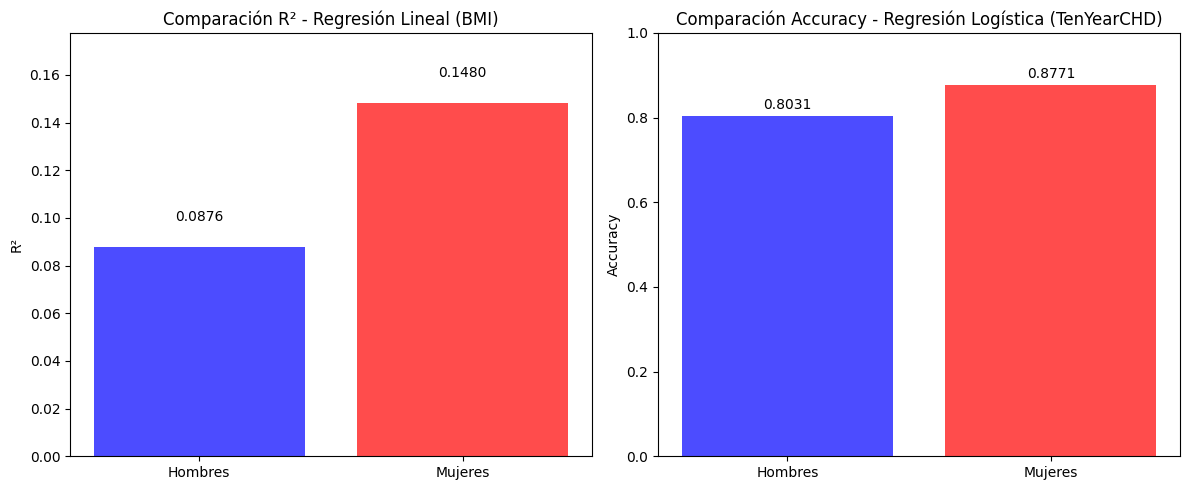

In [ ]:
# ===================================================================
# PARTE 3: VISUALIZACIÓN COMPARATIVA
# ===================================================================

# Gráfico comparativo de R² (Regresión Lineal)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
grupos_rl = ['Hombres', 'Mujeres']
r2_scores = [modelo_hombres_rl['r2'], modelo_mujeres_rl['r2']]
bars = plt.bar(grupos_rl, r2_scores, color=['blue', 'red'], alpha=0.7)
plt.title('Comparación R² - Regresión Lineal (BMI)')
plt.ylabel('R²')
plt.ylim(0, max(r2_scores) * 1.2)

# Añadir valores sobre las barras
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', va='bottom')

plt.subplot(1, 2, 2)
grupos_log = ['Hombres', 'Mujeres']
accuracy_scores = [modelo_hombres_log['accuracy'], modelo_mujeres_log['accuracy']]
bars = plt.bar(grupos_log, accuracy_scores, color=['blue', 'red'], alpha=0.7)
plt.title('Comparación Accuracy - Regresión Logística (TenYearCHD)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

# Añadir valores sobre las barras
for bar, score in zip(bars, accuracy_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [ ]:

# ===================================================================
# PARTE 4: CONCLUSIONES
# ===================================================================

print(f"\n{'='*60}")
print(f"CONCLUSIONES DEL ANÁLISIS COMPARATIVO")
print(f"{'='*60}")

print(f"\n1. REGRESIÓN LINEAL (BMI):")
print(f"   - Modelo Hombres: R² = {modelo_hombres_rl['r2']:.4f}")
print(f"   - Modelo Mujeres: R² = {modelo_mujeres_rl['r2']:.4f}")
print(f"   - Diferencia: {abs(modelo_hombres_rl['r2'] - modelo_mujeres_rl['r2']):.4f}")

print(f"\n2. REGRESIÓN LOGÍSTICA (TenYearCHD):")
print(f"   - Modelo Hombres: Accuracy = {modelo_hombres_log['accuracy']:.4f}")
print(f"   - Modelo Mujeres: Accuracy = {modelo_mujeres_log['accuracy']:.4f}")
print(f"   - Diferencia: {abs(modelo_hombres_log['accuracy'] - modelo_mujeres_log['accuracy']):.4f}")

print(f"\n3. OBSERVACIONES:")
print(f"   - Tamaño muestras diferentes: Hombres ({modelo_hombres_rl['n_muestra']}) vs Mujeres ({modelo_mujeres_rl['n_muestra']})")
print(f"   - Balanceo desigual en regresión logística")
print(f"   - La separación por género revela diferencias en el comportamiento de las variables")

if modelo_hombres_rl['r2'] > modelo_mujeres_rl['r2'] and modelo_hombres_log['accuracy'] > modelo_mujeres_log['accuracy']:
    print(f"\n4. CONCLUSIÓN FINAL: Los modelos de Hombres muestran mejor rendimiento en ambos casos")
elif modelo_mujeres_rl['r2'] > modelo_hombres_rl['r2'] and modelo_mujeres_log['accuracy'] > modelo_hombres_log['accuracy']:
    print(f"\n4. CONCLUSIÓN FINAL: Los modelos de Mujeres muestran mejor rendimiento en ambos casos")
else:
    print(f"\n4. CONCLUSIÓN FINAL: El rendimiento varía según el tipo de modelo y el género")


CONCLUSIONES DEL ANÁLISIS COMPARATIVO

1. REGRESIÓN LINEAL (BMI):
   - Modelo Hombres: R² = 0.0876
   - Modelo Mujeres: R² = 0.1480
   - Diferencia: 0.0604

2. REGRESIÓN LOGÍSTICA (TenYearCHD):
   - Modelo Hombres: Accuracy = 0.8031
   - Modelo Mujeres: Accuracy = 0.8771
   - Diferencia: 0.0741

3. OBSERVACIONES:
   - Tamaño muestras diferentes: Hombres (1622) vs Mujeres (2034)
   - Balanceo desigual en regresión logística
   - La separación por género revela diferencias en el comportamiento de las variables

4. CONCLUSIÓN FINAL: Los modelos de Mujeres muestran mejor rendimiento en ambos casos
